### Importing the necessary Libraries 

In [5]:
import sys 
print(sys.executable)

c:\Users\getde\OneDrive\Documents\Mitu's folder\Personal\Stock Data Analysis\.venv\Scripts\python.exe


#### ipywidgets Creates interactive dropdown menus and date selectors inside the notebook.
##### Example usage:
######  selecting stock ticker
######  selecting analysis period

In [6]:
import ipywidgets
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk")
print ("Import OK")

Import OK


### Ticker selection widget

In [7]:
# Create a dropdown for ticker selection
tickers = ['TSLA', 'AAPL', 'GOOGL', 'MSFT', 'AMZN', 'META', 'NVDA', 'JPM', 'V', 'DIS']
ticker_dropdown = ipywidgets.Dropdown(
    options=tickers,
    value='TSLA',
    description='Ticker:'
)

### Selecting Stock Ticker

In this section, a dropdown widget is created to allow the user to select a stock symbol for analysis.

Example tickers include:

TSLA
AAPL
MSFT
AMZN
META
NVDA

This makes the notebook interactive and flexible.

### Selecting Date Range

Here, users define the start and end dates for downloading historical stock data.

This allows analysis for different time periods depending on research needs.

In [8]:
start_date = ipywidgets.DatePicker(
    description='Pick a Start Date'
)
end_date = ipywidgets.DatePicker(
    description='Pick a End Date'
)

### Interactive Input: Select Ticker & Date Range

In [10]:
display(ticker_dropdown, start_date, end_date)

Dropdown(description='Ticker:', index=5, options=('TSLA', 'AAPL', 'GOOGL', 'MSFT', 'AMZN', 'META', 'NVDA', 'JP…

DatePicker(value=datetime.date(2026, 1, 1), description='Pick a Start Date', step=1)

DatePicker(value=datetime.date(2026, 3, 6), description='Pick a End Date', step=1)

### Ticker Dropdown

In [11]:
ticker = ticker_dropdown.value
start= start_date.value
end= end_date.value

### Downloading Stock Data

Stock price data is downloaded using the yfinance library.

The dataset includes:

 - Open price
 - High price
 - Low price
 - Close price
 - Adjusted close price
 - Trading volume

This dataset forms the basis of the entire analysis.

In [12]:
data = yf.download(ticker, start=start, end=end, auto_adjust=True).dropna()
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,META,META,META,META,META
Date,,,,,
2026-01-02,649.853577,663.821659,642.949515,662.163045,13726500
2026-01-05,658.226440,663.971522,647.195906,650.453127,12213700
2026-01-06,660.054871,664.950703,651.342359,659.005781,11074400
2026-01-07,648.135071,658.586145,644.258385,655.079138,12846300
2026-01-08,645.507324,646.546413,635.176143,645.327486,11921700


### Summary Statistics

This section computes descriptive statistics of stock prices.

Examples include:

 - mean
 - standard deviation
 - minimum value
 - maximum value
 - quartiles

These statistics help understand price variability and distribution.

In [13]:
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,META,META,META,META,META
count,43.000000,43.000000,43.000000,43.000000,4.300000e+01
mean,655.250613,663.879742,645.951135,655.248059,1.548956e+07
std,25.680053,27.512351,24.809959,27.988225,7.865008e+06
min,603.603210,610.877012,599.486740,606.220958,8.605900e+06
25%,642.045258,647.760393,633.992188,639.047878,1.206770e+07
50%,653.130798,660.434575,642.949515,650.453127,1.418350e+07
75%,668.137939,675.831390,656.822615,664.740840,1.601520e+07
max,737.678406,743.363541,712.979601,736.799154,5.985290e+07


### Visualizing the stock's Closing price

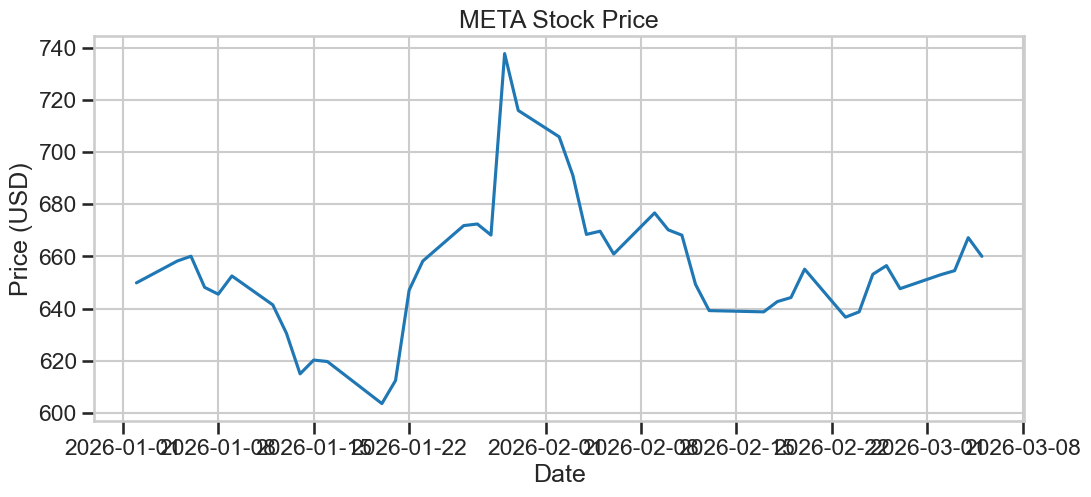

<Figure size 640x480 with 0 Axes>

In [14]:
plt.figure(figsize=(12,5))
plt.plot(data['Close'])
plt.title(f"{ticker} Stock Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.show()
plt.savefig(f"{ticker}.jpg", dpi=300, bbox_inches='tight')

### Calculating Daily Returns

Daily returns measure percentage change in stock price between consecutive trading days.

Formula:

Return = (Price_today − Price_yesterday) / Price_yesterday

This indicator is essential for risk and performance analysis.

In [15]:
data['Return']= data['Close'].pct_change()
data[['Close','Return']].head()

Price,Close,Return
Ticker,META,
Date,,
2026-01-02,649.853577,NaN
2026-01-05,658.226440,0.012884
2026-01-06,660.054871,0.002778
2026-01-07,648.135071,-0.018059
2026-01-08,645.507324,-0.004054


### Daily Returns Visualization

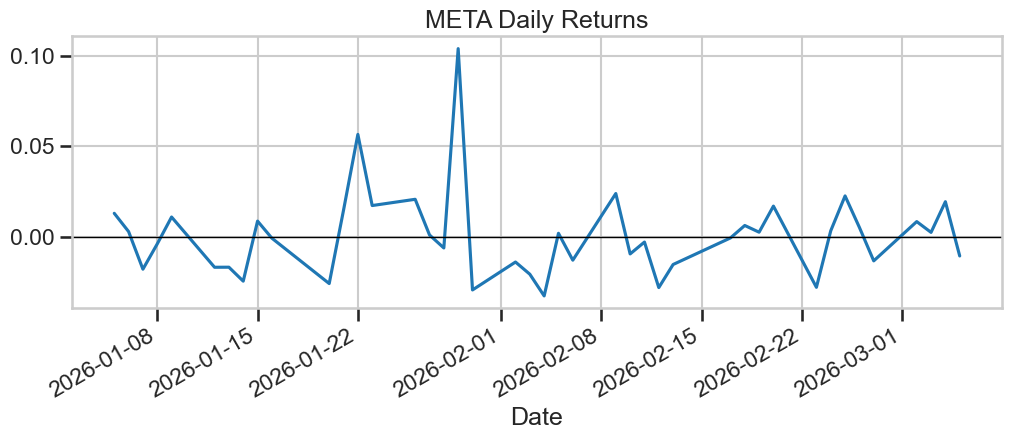

<Figure size 640x480 with 0 Axes>

In [16]:
plt.figure(figsize=(12,4))
data['Return'].plot()
plt.axhline(0,color='black',linewidth=1)
plt.title(f"{ticker} Daily Returns")
plt.show()
plt.savefig(f"{ticker}_daily_returns.png")

### Moving Averages (MA20 & MA50)

Moving averages smooth short-term price fluctuations and highlight long-term trends.

Two indicators are calculated:

 - 20-day moving average
 - 50-day moving average

These help detect momentum and trend direction.

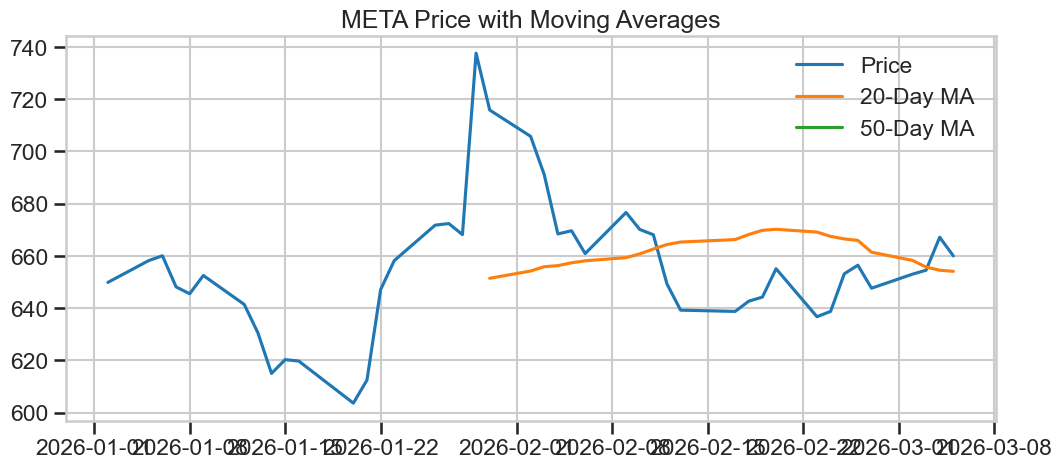

<Figure size 640x480 with 0 Axes>

In [17]:
data['MA20'] = data['Close'].rolling(20).mean()
data['MA50'] = data['Close'].rolling(50).mean()
plt.figure(figsize=(12,5))
plt.plot(data['Close'], label="Price")
plt.plot(data['MA20'], label="20-Day MA")
plt.plot(data['MA50'],label="50-Day MA")
plt.legend()
plt.title(f"{ticker} Price with Moving Averages")
plt.show()
plt.savefig(f"{ticker}_price_moving_averages.png")

### Daily Returns Statistics 

In [18]:
daily_mean =data['Return'].mean()
daily_vol =data['Return'].std()
ann_mean =daily_mean *252
ann_vol =daily_vol *np.sqrt(252)
print("Mean Daily Return:", daily_mean)
print("Daily Volatility:", daily_vol)
print("Annualized Mean Return:", ann_mean)
print("Annualized Volatility:", ann_vol)

Mean Daily Return: 0.0006512321299352387
Daily Volatility: 0.024403288405618336
Annualized Mean Return: 0.16411049674368017
Annualized Volatility: 0.3873901937607122


### Distribution of Daily Returns 

This section visualizes the statistical distribution of daily returns using histograms.

It helps analyze:

volatility, skewness, extreme movements

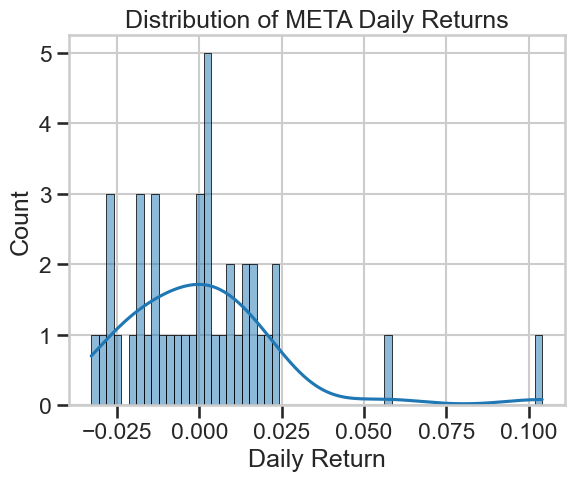

<Figure size 640x480 with 0 Axes>

In [19]:
sns.histplot(data['Return'].dropna(), bins=60, kde=True)
plt.title(f"Distribution of {ticker} Daily Returns")
plt.xlabel("Daily Return")
plt.show()
plt.savefig(f"Distribution_of_{ticker}_Daily_Returns.png")

### Rolling 20-Day Volatility

Rolling volatility measures variation in returns over a moving time window. Here, 20-day rolling standard deviation is used to estimate short-term risk. Higher volatility indicates higher uncertainty.

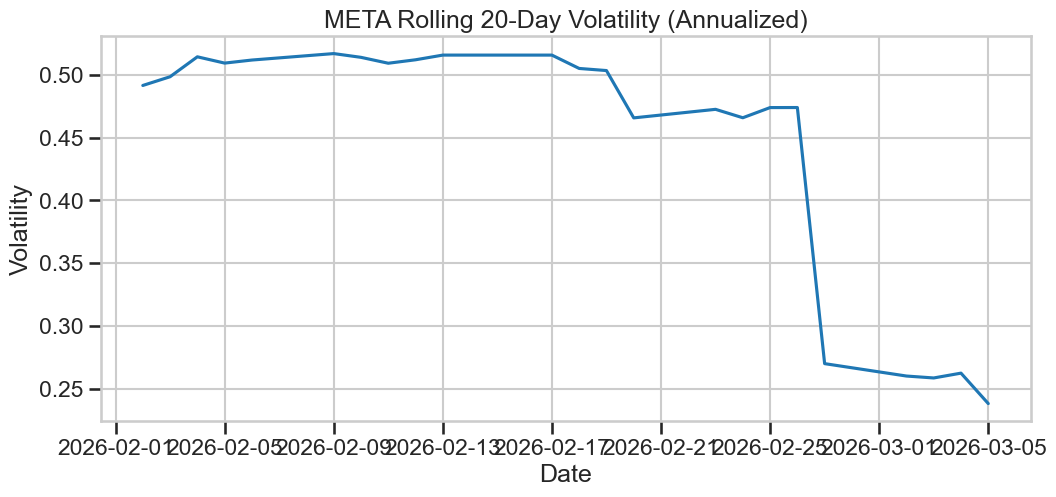

In [20]:
#Rolling 20-day volatility (annualized)
rolling_vol =data['Return'].rolling(20).std() * np.sqrt(252)
plt.figure(figsize=(12,5))
plt.plot(rolling_vol)
plt.title(f"{ticker} Rolling 20-Day Volatility (Annualized)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()

### Cumulative growth of $1 investment

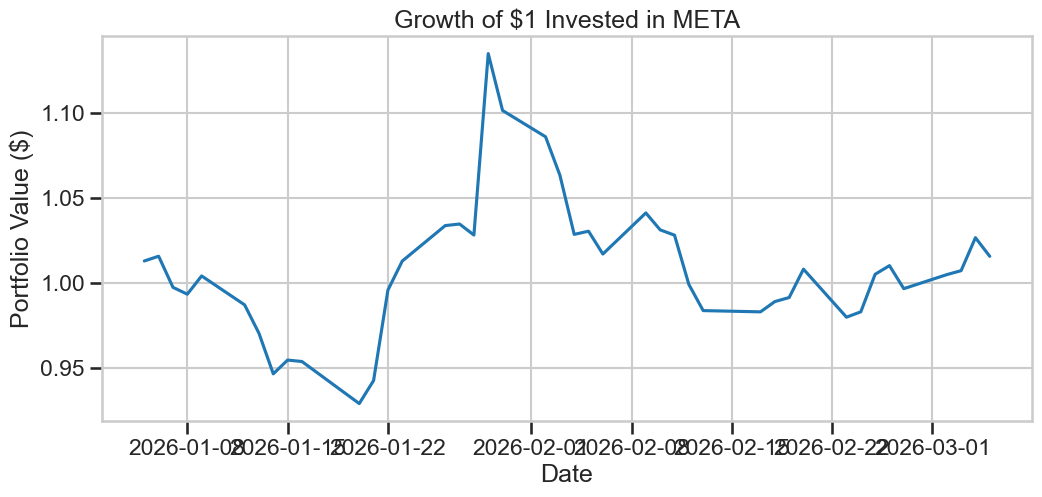

In [21]:
#Cumulative growth of $1 investment
wealth = (1+ data['Return']).cumprod()
plt.figure(figsize=(12,5))
plt.plot(wealth)
plt.title(f"Growth of $1 Invested in {ticker}")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.show() 

### Drawdown Analysis

Drawdown measures the decline from a previous peak in stock value.

It helps identify:

 - maximum losses
 - recovery periods
 - downside risk exposure

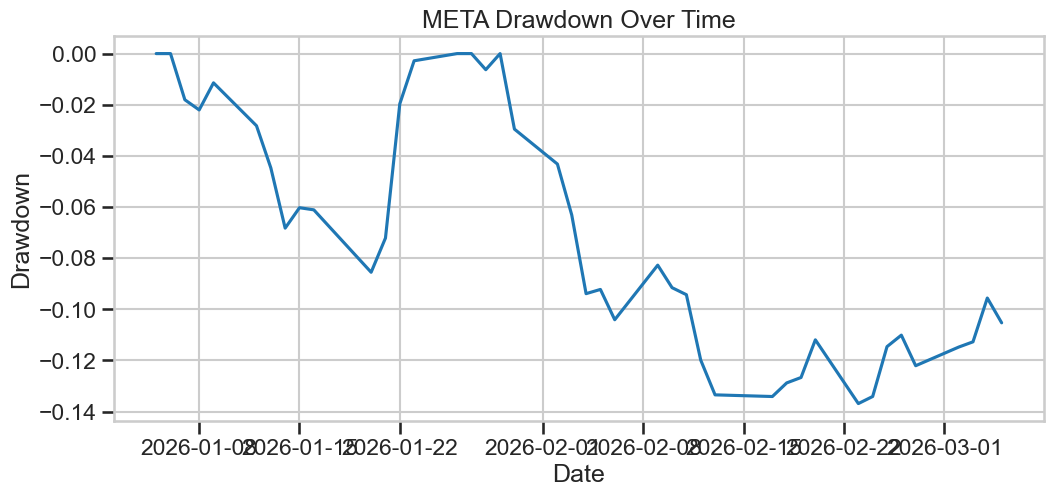

Maximum Drawdown: -0.13688012276558792


In [22]:
# Drawdown
roll_max = wealth.cummax()
drawdown = wealth /roll_max - 1.0
plt.figure(figsize=(12,5))
plt.plot(drawdown)
plt.title(f"{ticker} Drawdown Over Time")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.show()
#Maximum drawdown
print("Maximum Drawdown:", drawdown.min())

### Benchmark Comparison : Correlation and Beta with S&P 500

This section compares stock performance with the S&P 500 index.

It calculates the correlation with market index and beta coefficient. These indicators show how strongly the stock moves with the market.

In [23]:
#Benchmark (S&P 500)
bench = "^GSPC"
bench_px =yf.download(bench, start=start, end=end, auto_adjust=True)["Close"]
bench_ret = bench_px.pct_change()

combined =pd.concat([data['Return'], bench_ret], axis=1)
combined.columns = [ticker, 'SP500']
combined.dropna(inplace=True)
##Correlation
corr = combined.corr().iloc[0,1]
# Beta = Cov(f"{ticker}", SP500) /Var(SP500)
beta = combined.cov().iloc[0,1]/combined['SP500'].var()
print("Correlation with S&P 500:", corr)
print("Beta:",beta)

[*********************100%***********************]  1 of 1 completed

Correlation with S&P 500: 0.39155097210499595
Beta: 1.2708847687760343


In [24]:
# 1-year=252 trading days
N=252
dt=1/N
s0= data['Close'].iloc[-1].values[0]
#For estimation of return we use log returns
log_ret = np.log1p(data['Return'].dropna())
mu_daily = log_ret.mean()
sigma_daily = log_ret.std(ddof=1)
## Convert to annulized parameters 
mu_annual = mu_daily * 252
sigma_annual = sigma_daily * np.sqrt(252)
print(f"Estimated µ annually : {mu_annual:.4f}")
print(f"Estimated Volatility annually : {sigma_annual:.4f}")
print(f"S0 (last price) : {s0:.2f}")

Estimated µ annually : 0.0930
Estimated Volatility annually : 0.3788
S0 (last price) : 660.00


In [25]:
np.random.seed(999)
paths_n = 1000
S = np.zeros((N+1, paths_n))
S[0] = s0

for t in range(1, N+1):
    z= np.random.standard_normal(paths_n)
## GBM step 
    S[t] = S[t-1] * np.exp((mu_daily - 0.5*sigma_daily**2)*dt + sigma_daily*np.sqrt(dt)*z)
## Quick sanity checks
S.shape, S[0,0], S[-1,0]

((253, 1000), np.float64(660.0049438476562), np.float64(656.0507219019131))

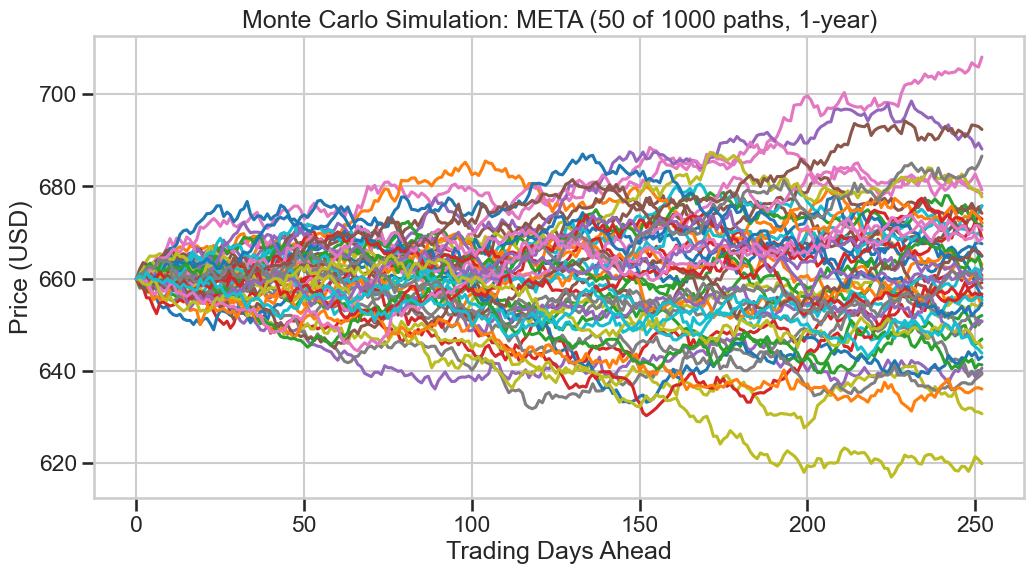

<Figure size 640x480 with 0 Axes>

In [26]:
plt.figure(figsize=(12,6))
plt.plot(S[:, :50])
plt.title(f"Monte Carlo Simulation: {ticker} (50 of 1000 paths, 1-year)")
plt.xlabel("Trading Days Ahead")
plt.ylabel("Price (USD)")
plt.show()
plt.savefig(f"Monte Carlo Simulation: {ticker}")

Expected terminal price (mean) : 660.49
Median terminal price          : 660.40
5th/25th/50th/75th/95th percentiles : 634.72, 650.71, 660.40, 671.32, 686.77


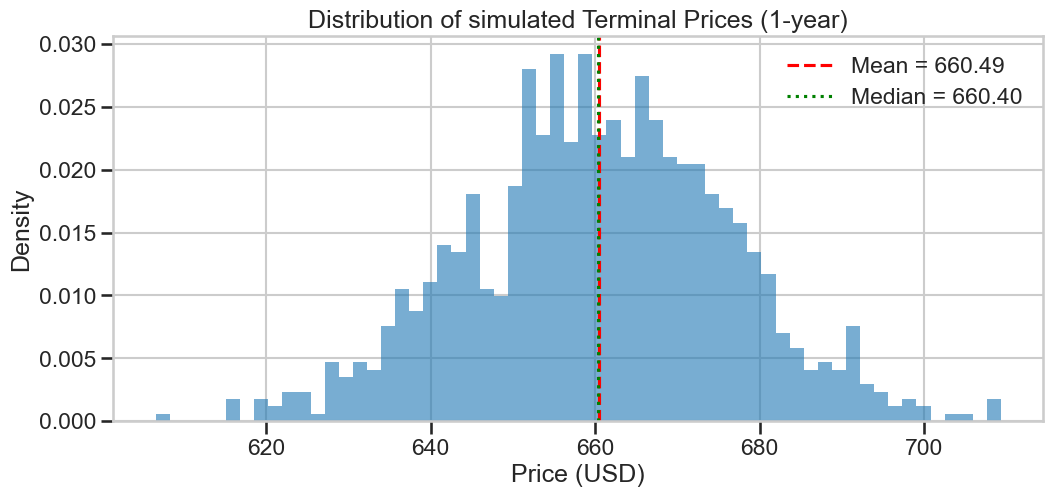

<Figure size 640x480 with 0 Axes>

In [27]:
terminal = S[-1]
exp_terminal = terminal.mean()
median_terminal = np.median(terminal)
p05, p25, p50, p75, p95 = np.percentile(terminal, [5, 25, 50, 75, 95])
print(f"Expected terminal price (mean) : {exp_terminal:.2f}")
print(f"Median terminal price          : {median_terminal:.2f}")
print(f"5th/25th/50th/75th/95th percentiles : {p05:.2f}, {p25:.2f}, {p50:.2f}, {p75:.2f}, {p95:.2f}")
plt.figure(figsize=(12,5))
plt.hist(terminal, bins=60, density=True, alpha=0.6)
plt.axvline(exp_terminal, color='r', linestyle='--', label=f"Mean = {exp_terminal:.2f}")
plt.axvline(median_terminal, color='g', linestyle=':', label=f"Median = {median_terminal:.2f}")
plt.title("Distribution of simulated Terminal Prices (1-year)")
plt.xlabel("Price (USD)")
plt.ylabel("Density")
plt.legend()
plt.show()
plt.savefig("Distribution of simulated Terminal Prices")

In [28]:
terminal = S[-1]
S0 = data['Close'].iloc[-1].values[0]
terminal_ret = terminal / S0 - 1.0
var_95 = np.percentile(terminal_ret, 5) # 5% left tail
es_95 = terminal_ret[terminal_ret <= var_95].mean() 
print(f"1Y 95% VaR (return): {var_95:.2%}")
print(f"1Y 95% CVaR/ES     : {es_95:.2%}")

1Y 95% VaR (return): -3.83%
1Y 95% CVaR/ES     : -4.97%


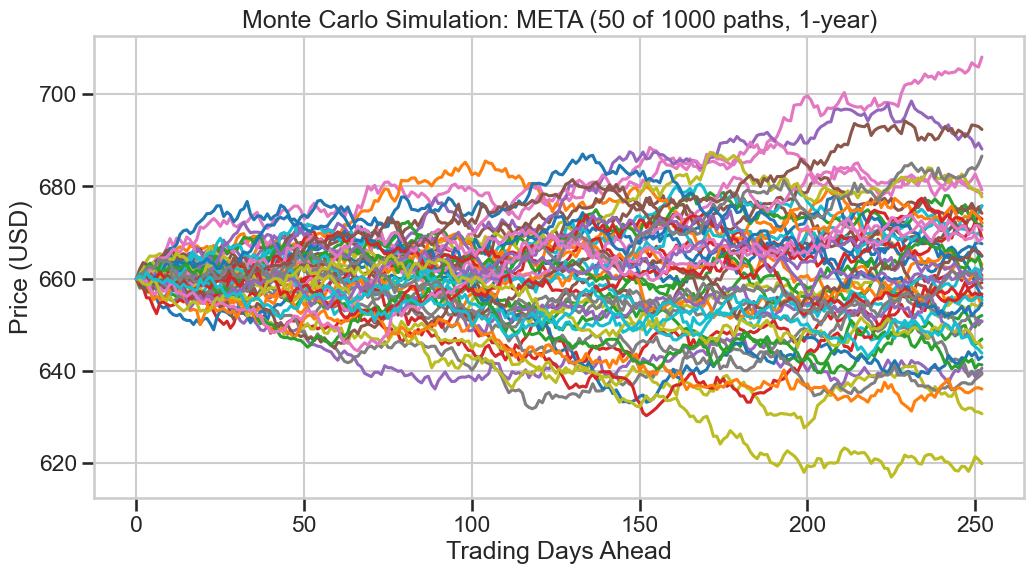

In [29]:
plt.figure(figsize=(12,6))
plt.plot(S[:, :50])
plt.title(f"Monte Carlo Simulation: {ticker} (50 of 1000 paths, 1-year)")
plt.xlabel("Trading Days Ahead")
plt.ylabel("Price (USD)")
plt.savefig(f"{ticker}_mc_paths.png", dpi=150, bbox_inches="tight")

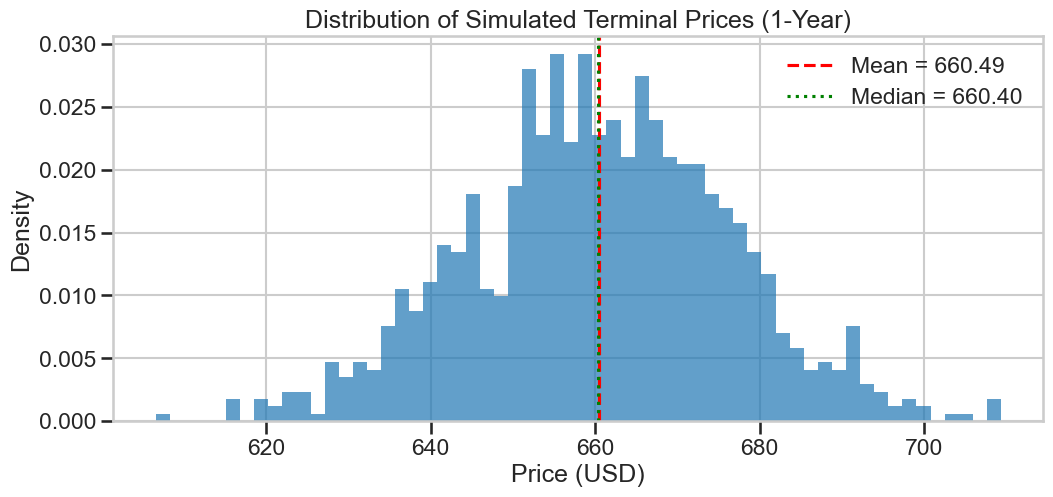

In [30]:
plt.figure(figsize= (12,5))
plt.hist(terminal, bins=60, density=True, alpha=0.7)
plt.axvline(exp_terminal, color='r', linestyle='--', label=f"Mean = {exp_terminal:.2f}")
plt.axvline(median_terminal, color='g', linestyle=':', label=f"Median = {median_terminal:.2f}")
plt.title("Distribution of Simulated Terminal Prices (1-Year)")
plt.xlabel("Price (USD)")
plt.ylabel("Density")
plt.legend()
plt.savefig(f"{ticker}_mc_terminal.png", dpi=150, bbox_inches="tight")

# Conclusion

This notebook demonstrates how Python can be used to analyze financial time series data interactively.

The analysis provides insights into:

 - return behavior
 - volatility patterns
 - investment growth
 - market sensitivity

Such techniques are widely used in quantitative finance and portfolio analysis.